In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

In [2]:
df = pd.read_excel("data/ApexPlanet_DataAnalytics_Dataset.xlsx")

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [4]:
df.tail()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
995,ORD100997,2025-11-07,CUST6410,Customer_301,61.0,Male,Gaya,Laptop,Electronics,9,35405.54,318649.86
996,ORD100998,2025-09-03,CUST7618,Customer_154,25.0,Male,Gaya,Shoes,Fashion,5,18454.65,92273.25
997,ORD100999,2025-09-30,CUST9544,Customer_140,62.0,Female,Hyderabad,Laptop,Electronics,9,12971.59,116744.31
998,ORD101000,2025-02-21,CUST9501,Customer_241,NaN,Male,Delhi,Mobile,Electronics,9,2879.01,25911.09
999,ORD101001,2025-04-23,CUST2714,Customer_98,58.0,Female,Gaya,Chair,Furniture,9,22493.87,202444.83


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 12


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


In [7]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [8]:
df.ffill(inplace=True)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD100997,2025-11-07,CUST6410,Customer_301,61.0,Male,Gaya,Laptop,Electronics,9,35405.54,318649.86
996,ORD100998,2025-09-03,CUST7618,Customer_154,25.0,Male,Gaya,Shoes,Fashion,5,18454.65,92273.25
997,ORD100999,2025-09-30,CUST9544,Customer_140,62.0,Female,Hyderabad,Laptop,Electronics,9,12971.59,116744.31
998,ORD101000,2025-02-21,CUST9501,Customer_241,62.0,Male,Delhi,Mobile,Electronics,9,2879.01,25911.09


In [9]:
print(df.duplicated().sum())

0


In [10]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.404000,5.435000,25486.783410,139399.439650
std,13.865101,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [11]:
df.describe(include="all")

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
count,1000,1000,1000,1000,1000.000000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000
unique,992,342,947,425,NaN,2,8,6,5,NaN,NaN,NaN
top,ORD100050,2025-04-16,CUST2515,Customer_359,NaN,Male,Kolkata,Mobile,Electronics,NaN,NaN,NaN
freq,9,10,3,8,NaN,511,137,184,354,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,41.404000,NaN,NaN,NaN,NaN,5.435000,25486.783410,139399.439650
std,NaN,NaN,NaN,NaN,13.865101,NaN,NaN,NaN,NaN,2.838632,14179.402361,114100.051546
min,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,1.000000,145.780000,437.340000
25%,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,3.000000,13895.722500,47066.632500
50%,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,5.000000,25398.740000,108594.025000
75%,NaN,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,8.000000,37512.382500,203722.882500


In [12]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()

df["Year"] = df["Order_Date"].dt.year

In [13]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Month,Year
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,February,2025
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,October,2025
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,May,2025
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,December,2025
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,November,2025


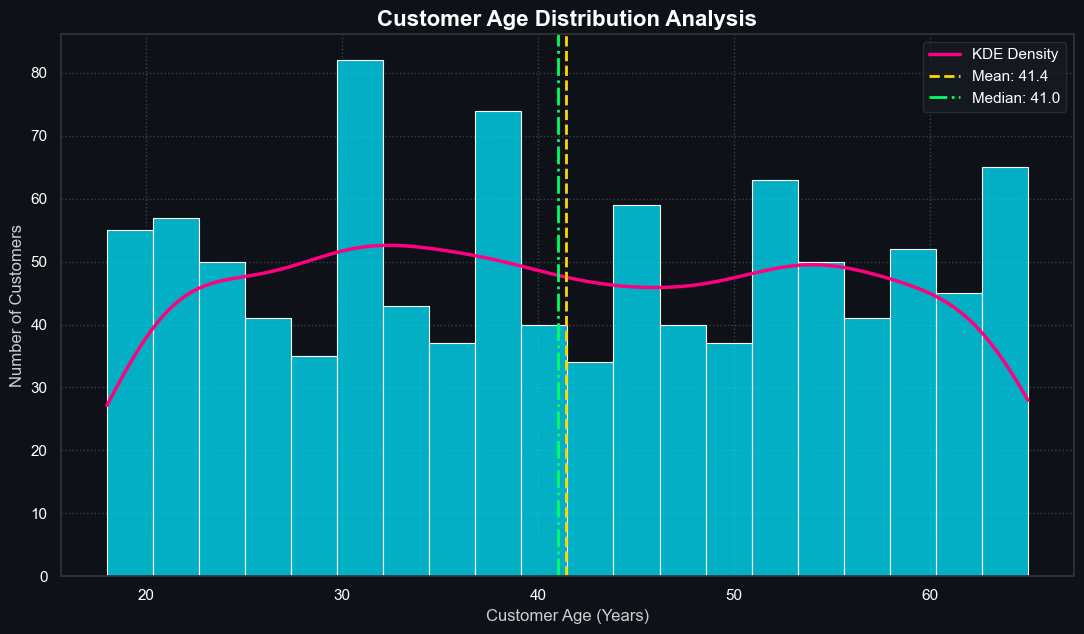

In [31]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='#0E1117')
ax.set_facecolor('#0E1117')

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="#00E5FF",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.75,
    ax=ax
)

if ax.lines:
    ax.lines[0].set_color("#FF007F")
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_label("KDE Density")

mean_val = df["Age"].mean()
median_val = df["Age"].median()
total_count = len(df["Age"].dropna())

line_mean = ax.axvline(
    mean_val,
    color="#FFD700",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_val:.1f}"
)

line_med = ax.axvline(
    median_val,
    color="#00FF66",
    linestyle="-.",
    linewidth=2,
    label=f"Median: {median_val:.1f}"
)

ax.set_title(
    "Customer Age Distribution Analysis",
    fontsize=16,
    fontweight="bold",
    color="white"
)

ax.set_xlabel("Customer Age (Years)", fontsize=12, color="#CCCCCC")
ax.set_ylabel("Number of Customers", fontsize=12, color="#CCCCCC")

ax.grid(True, linestyle=":", alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("#333333")

ax.legend(
    facecolor="#161B22",
    edgecolor="#333333",
    labelcolor="white",
    loc="upper right"
)

cursor = mplcursors.cursor(ax.patches, hover=True)

@cursor.connect("add")
def _(sel):
    patch = sel.artist
    height = patch.get_height()
    left = patch.get_x()
    right = left + patch.get_width()
    pct = height / total_count * 100

    for p in ax.patches:
        p.set_alpha(0.25)

    patch.set_alpha(1)

    sel.annotation.set_text(
        f"Age : {left:.1f} - {right:.1f}\n"
        f"Customers : {int(height)}\n"
        f"Percentage : {pct:.1f}%"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(fc="#1E2640", ec="#00E5FF", lw=1.5, alpha=0.95)

    sel.annotation.get_txt().set_color("white")

@cursor.connect("remove")
def _(sel):
    for p in ax.patches:
        p.set_alpha(0.75)

line_cursor = mplcursors.cursor([line_mean, line_med], hover=True)

@line_cursor.connect("add")
def _(sel):
    sel.annotation.set_text(sel.artist.get_label())
    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#161B22",
        ec=sel.artist.get_color(),
        lw=1.5,
        alpha=0.95
    )
    sel.annotation.get_txt().set_color("white")

plt.tight_layout()
plt.show()

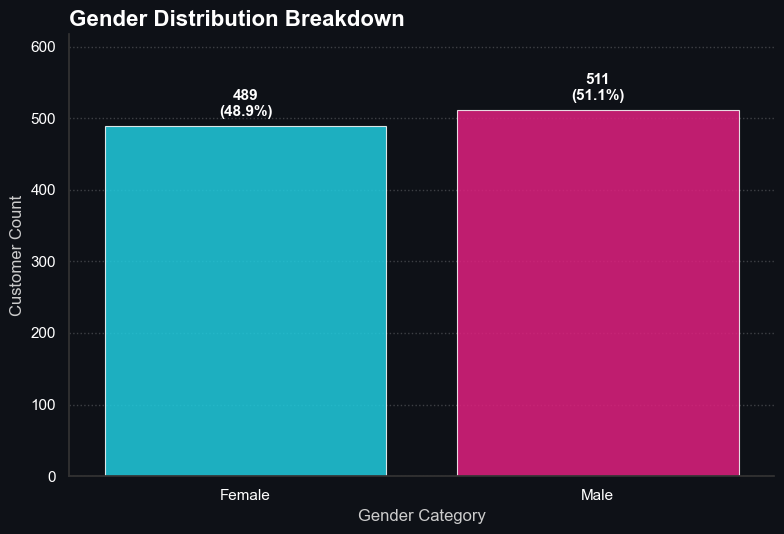

In [32]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor='#0E1117')
ax.set_facecolor('#0E1117')

colors = ["#00E5FF", "#FF007F", "#7B2CBF", "#00FF66"]

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette=colors[:len(df["Gender"].unique())],
    legend=False,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    ax=ax
)

total = len(df["Gender"].dropna())

for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        pct = (height / total) * 100
        ax.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (patch.get_x() + patch.get_width()/2, height),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=11,
            fontweight="bold",
            color="white"
        )

cursor = mplcursors.cursor(ax.patches, hover=True)

@cursor.connect("add")
def _(sel):
    patch = sel.artist
    category = ax.get_xticklabels()[int(patch.get_x() + patch.get_width()/2)].get_text()
    height = patch.get_height()
    pct = (height / total) * 100

    for p in ax.patches:
        p.set_alpha(0.25)

    patch.set_alpha(1)

    sel.annotation.set_text(
        f"Gender : {category}\n"
        f"Customers : {int(height):,}\n"
        f"Percentage : {pct:.1f}%"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#1E2640",
        ec="#00E5FF",
        lw=1.5,
        alpha=0.95,
        boxstyle="round,pad=0.5"
    )

    sel.annotation.get_txt().set_color("white")

@cursor.connect("remove")
def _(sel):
    for p in ax.patches:
        p.set_alpha(0.85)

ax.set_title(
    "Gender Distribution Breakdown",
    fontsize=16,
    fontweight="bold",
    color="white",
    loc="left"
)

ax.set_xlabel(
    "Gender Category",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_ylabel(
    "Customer Count",
    fontsize=12,
    color="#CCCCCC"
)

ax.grid(axis="y", linestyle=":", alpha=0.2)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

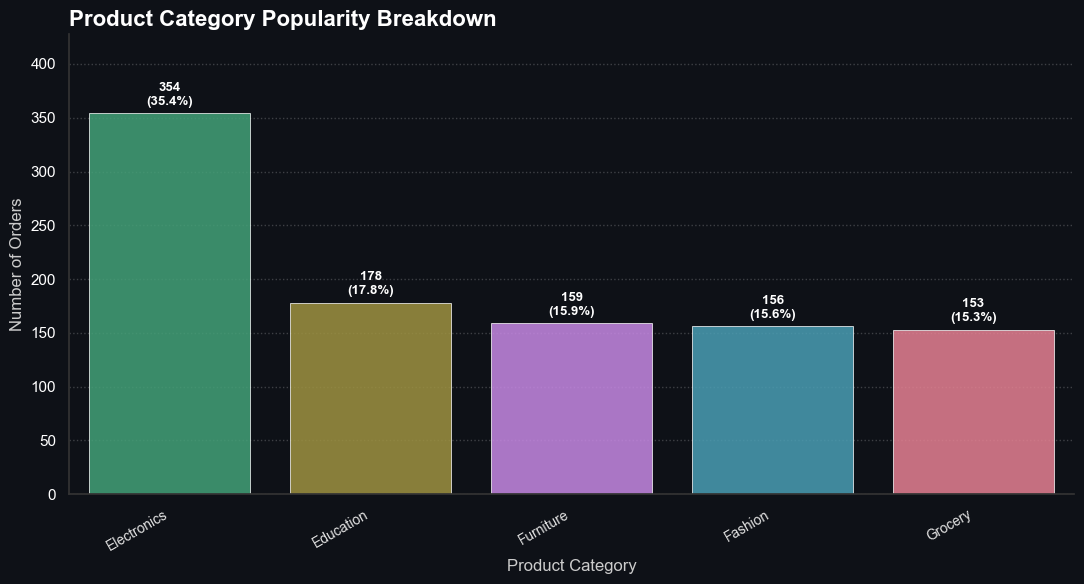

In [33]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6), facecolor='#0E1117')
ax.set_facecolor('#0E1117')

category_order = df["Category"].value_counts().index
total_count = len(df["Category"].dropna())

palette = sns.color_palette("husl", n_colors=len(category_order))

sns.countplot(
    data=df,
    x="Category",
    order=category_order,
    hue="Category",
    palette=palette,
    legend=False,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.85,
    ax=ax
)

for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        pct = (height / total_count) * 100
        ax.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (patch.get_x() + patch.get_width()/2, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=9.5,
            fontweight="bold",
            color="white"
        )

cursor = mplcursors.cursor(ax.patches, hover=True)

@cursor.connect("add")
def _(sel):
    patch = sel.artist
    category = ax.get_xticklabels()[int(patch.get_x() + patch.get_width()/2)].get_text()
    height = patch.get_height()
    pct = (height / total_count) * 100

    for p in ax.patches:
        p.set_alpha(0.20)

    patch.set_alpha(1)

    sel.annotation.set_text(
        f"Category : {category}\n"
        f"Orders : {int(height):,}\n"
        f"Percentage : {pct:.1f}%"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#1E2640",
        ec="#00E5FF",
        lw=1.5,
        alpha=0.95,
        boxstyle="round,pad=0.5"
    )

    sel.annotation.get_txt().set_color("white")

@cursor.connect("remove")
def _(sel):
    for p in ax.patches:
        p.set_alpha(0.85)

ax.set_title(
    "Product Category Popularity Breakdown",
    fontsize=16,
    fontweight="bold",
    color="white",
    loc="left"
)

ax.set_xlabel(
    "Product Category",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_ylabel(
    "Number of Orders",
    fontsize=12,
    color="#CCCCCC"
)

plt.xticks(rotation=30, ha="right", fontsize=10, color="#E0E0E0")

ax.grid(axis="y", linestyle=":", alpha=0.2)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

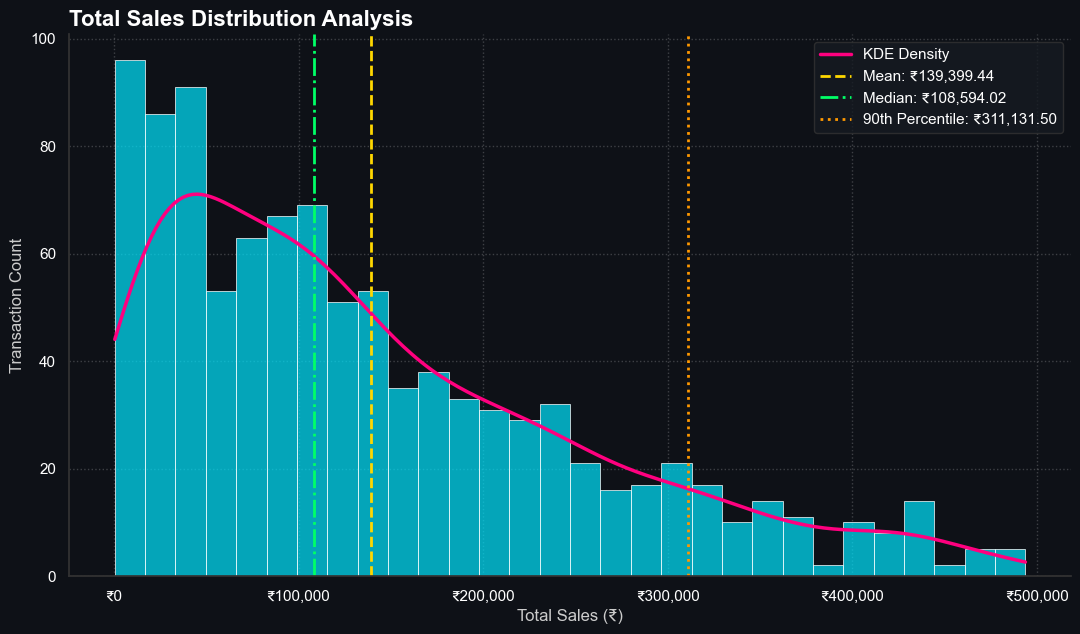

In [34]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='#0E1117')
ax.set_facecolor('#0E1117')

sales_data = df["Total_Sales"].dropna()
total_count = len(sales_data)

mean_sales = sales_data.mean()
median_sales = sales_data.median()
p90_sales = np.percentile(sales_data, 90)

sns.histplot(
    data=df,
    x="Total_Sales",
    bins=30,
    kde=True,
    color="#00E5FF",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.70,
    ax=ax
)

if ax.lines:
    ax.lines[0].set_color("#FF007F")
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_label("KDE Density")

line_mean = ax.axvline(
    mean_sales,
    color="#FFD700",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ₹{mean_sales:,.2f}"
)

line_median = ax.axvline(
    median_sales,
    color="#00FF66",
    linestyle="-.",
    linewidth=2,
    label=f"Median: ₹{median_sales:,.2f}"
)

line_p90 = ax.axvline(
    p90_sales,
    color="#FF9800",
    linestyle=":",
    linewidth=2,
    label=f"90th Percentile: ₹{p90_sales:,.2f}"
)

cursor = mplcursors.cursor(ax.patches, hover=True)

@cursor.connect("add")
def _(sel):
    patch = sel.artist
    height = patch.get_height()
    left = patch.get_x()
    right = left + patch.get_width()
    pct = (height / total_count) * 100

    for p in ax.patches:
        p.set_alpha(0.20)

    patch.set_alpha(1)

    sel.annotation.set_text(
        f"Sales Range : ₹{left:,.0f} - ₹{right:,.0f}\n"
        f"Transactions : {int(height):,}\n"
        f"Percentage : {pct:.1f}%"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#1E2640",
        ec="#00E5FF",
        lw=1.5,
        alpha=0.95,
        boxstyle="round,pad=0.5"
    )

    sel.annotation.get_txt().set_color("white")

@cursor.connect("remove")
def _(sel):
    for p in ax.patches:
        p.set_alpha(0.70)

line_cursor = mplcursors.cursor([line_mean, line_median, line_p90], hover=True)

@line_cursor.connect("add")
def _(sel):
    sel.annotation.set_text(sel.artist.get_label())

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#161B22",
        ec=sel.artist.get_color(),
        lw=1.5,
        alpha=0.95
    )

    sel.annotation.get_txt().set_color("white")

ax.set_title(
    "Total Sales Distribution Analysis",
    fontsize=16,
    fontweight="bold",
    color="white",
    loc="left"
)

ax.set_xlabel(
    "Total Sales (₹)",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_ylabel(
    "Transaction Count",
    fontsize=12,
    color="#CCCCCC"
)

from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
)

ax.grid(True, linestyle=":", alpha=0.2)

ax.legend(
    facecolor="#161B22",
    edgecolor="#333333",
    labelcolor="white",
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

plt.tight_layout()
plt.show()

In [23]:
top_products = (
    df.groupby("Product")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

top_products

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Name: Total_Sales, dtype: float64

In [24]:
category_sales = df.groupby("Category")["Total_Sales"].sum()

category_sales.sort_values(ascending=False)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

In [25]:
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

monthly_sales

Month
April        12222700.17
August        9448471.22
December     12299904.44
February     11511181.46
January      10905580.72
July         11746226.80
June         12912332.64
March        13059899.94
May          10984689.25
November     12627620.22
October      12500936.50
September     9179896.29
Name: Total_Sales, dtype: float64

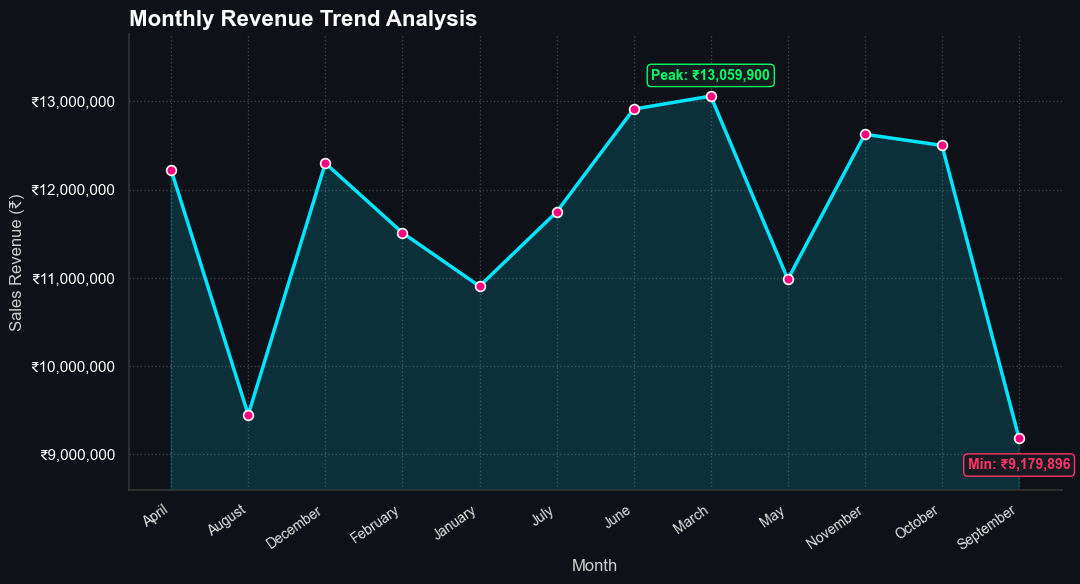

In [35]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6), facecolor="#0E1117")
ax.set_facecolor("#0E1117")

x_data = np.arange(len(monthly_sales))
y_data = monthly_sales.values
labels = monthly_sales.index.astype(str)

line, = ax.plot(
    x_data,
    y_data,
    color="#00E5FF",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="#FF007F",
    markeredgecolor="white",
    markeredgewidth=1.2,
    label="Monthly Sales"
)

ax.fill_between(
    x_data,
    y_data,
    color="#00E5FF",
    alpha=0.15
)

max_idx = np.argmax(y_data)
min_idx = np.argmin(y_data)

ax.annotate(
    f"Peak: ₹{y_data[max_idx]:,.0f}",
    (x_data[max_idx], y_data[max_idx]),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#00FF66",
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="#161B22",
        ec="#00FF66"
    )
)

ax.annotate(
    f"Min: ₹{y_data[min_idx]:,.0f}",
    (x_data[min_idx], y_data[min_idx]),
    xytext=(0, -22),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#FF3366",
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="#161B22",
        ec="#FF3366"
    )
)

cursor = mplcursors.cursor(line, hover=True)

@cursor.connect("add")
def _(sel):
    idx = int(round(sel.target[0]))
    idx = max(0, min(idx, len(labels)-1))

    sel.annotation.set_text(
        f"Month : {labels[idx]}\n"
        f"Sales : ₹{y_data[idx]:,.2f}"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#1E2640",
        ec="#00E5FF",
        lw=1.5,
        alpha=0.95,
        boxstyle="round,pad=0.5"
    )

    sel.annotation.get_txt().set_color("white")

ax.set_title(
    "Monthly Revenue Trend Analysis",
    fontsize=16,
    fontweight="bold",
    color="white",
    loc="left"
)

ax.set_xlabel(
    "Month",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_ylabel(
    "Sales Revenue (₹)",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_xticks(x_data)
ax.set_xticklabels(
    labels,
    rotation=35,
    ha="right",
    fontsize=10,
    color="#E0E0E0"
)

from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
)

ax.grid(True, linestyle=":", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

y_range = y_data.max() - y_data.min()

ax.set_ylim(
    y_data.min() - y_range*0.15,
    y_data.max() + y_range*0.18
)

plt.tight_layout()
plt.show()

In [27]:
city_sales = df.groupby("City")["Total_Sales"].sum()

city_sales.sort_values(ascending=False)

City
Kolkata      19515335.19
Patna        19285966.89
Bengaluru    18843355.83
Mumbai       18782386.87
Hyderabad    17166766.87
Delhi        16268650.86
Gaya         14912055.25
Pune         14624921.89
Name: Total_Sales, dtype: float64

In [28]:
df.groupby("Gender")["Total_Sales"].mean()

Gender
Female    136883.208630
Male      141807.339785
Name: Total_Sales, dtype: float64

In [29]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Mobile    1008
Book       977
Laptop     970
Chair      855
Rice       826
Shoes      799
Name: Quantity, dtype: int64

In [30]:
corr = df.select_dtypes(include=np.number).corr()

corr

,Age,Quantity,Unit_Price,Total_Sales,Year
Age,1.000000,-0.034862,-0.021773,-0.011801,0.034763
Quantity,-0.034862,1.000000,0.021855,0.646641,-0.015866
Unit_Price,-0.021773,0.021855,1.000000,0.686303,0.045437
Total_Sales,-0.011801,0.646641,0.686303,1.000000,0.013972
Year,0.034763,-0.015866,0.045437,0.013972,1.000000


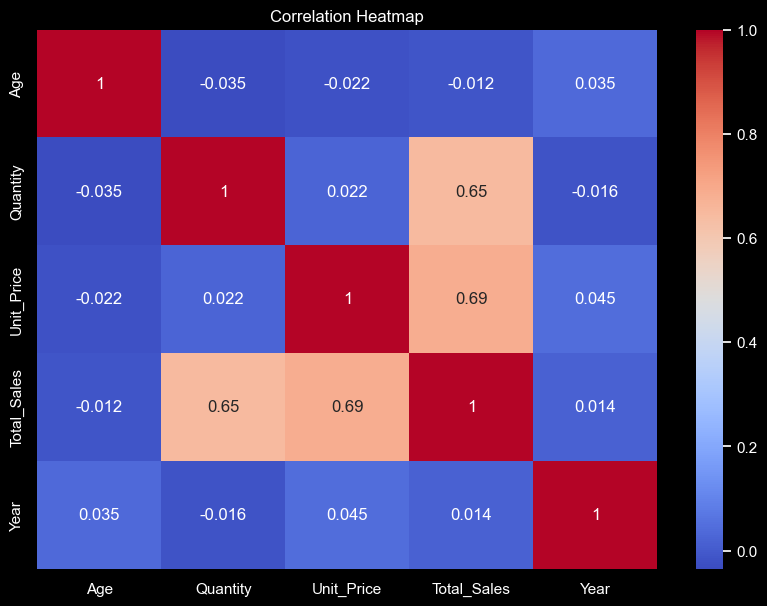

In [26]:
plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

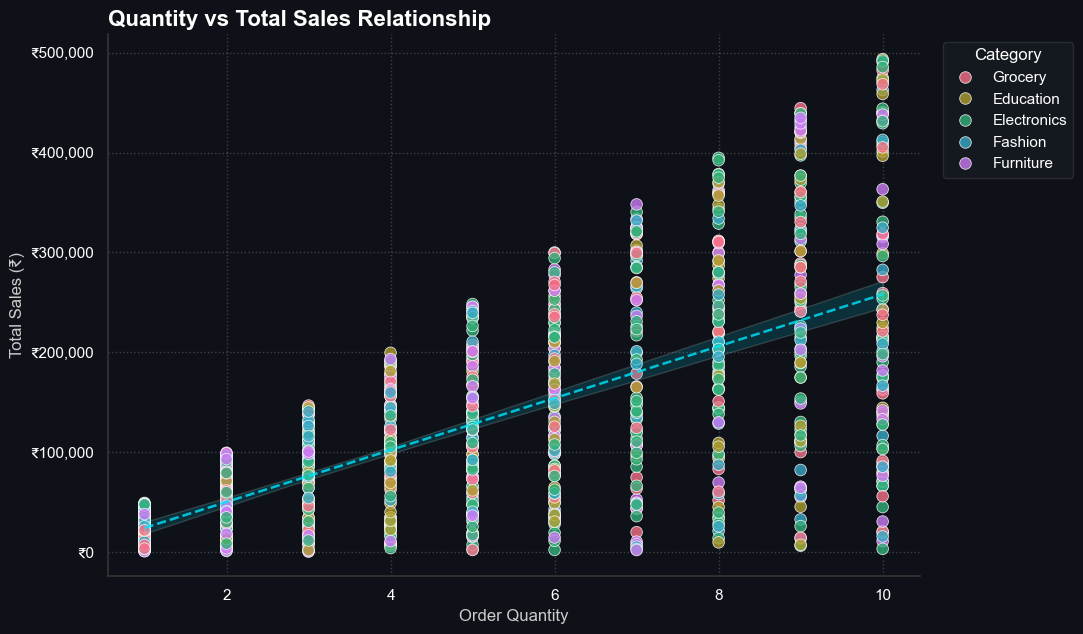

In [36]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="#0E1117")
ax.set_facecolor("#0E1117")

categories = df["Category"].dropna().unique()
palette = sns.color_palette("husl", n_colors=len(categories))

scatter = sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    hue="Category",
    palette=palette,
    s=70,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

sns.regplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    scatter=False,
    color="#00E5FF",
    line_kws={
        "linestyle": "--",
        "linewidth": 1.8,
        "alpha": 0.8,
        "label": "Trend Line"
    },
    ax=ax
)

cursor = mplcursors.cursor(ax.collections[0], hover=True)

@cursor.connect("add")
def _(sel):

    x_val = sel.target[0]
    y_val = sel.target[1]

    row = df[
        (df["Quantity"] == x_val) &
        (df["Total_Sales"] == y_val)
    ]

    if not row.empty:
        category = row.iloc[0]["Category"]
        product = row.iloc[0]["Product"]
    else:
        category = "Unknown"
        product = "Unknown"

    sel.annotation.set_text(
        f"Product : {product}\n"
        f"Category : {category}\n"
        f"Quantity : {int(x_val)}\n"
        f"Sales : ₹{y_val:,.2f}"
    )

    box = sel.annotation.get_bbox_patch()
    box.set(
        fc="#1E2640",
        ec="#00E5FF",
        lw=1.5,
        alpha=0.95,
        boxstyle="round,pad=0.5"
    )

    sel.annotation.get_txt().set_color("white")

ax.set_title(
    "Quantity vs Total Sales Relationship",
    fontsize=16,
    fontweight="bold",
    color="white",
    loc="left"
)

ax.set_xlabel(
    "Order Quantity",
    fontsize=12,
    color="#CCCCCC"
)

ax.set_ylabel(
    "Total Sales (₹)",
    fontsize=12,
    color="#CCCCCC"
)

from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
)

ax.legend(
    title="Category",
    facecolor="#161B22",
    edgecolor="#333333",
    labelcolor="white",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.get_legend().get_title().set_color("white")

ax.grid(True, linestyle=":", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

plt.tight_layout()
plt.show()

In [14]:
%pip install mplcursors

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
%pip install ipympl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
